Use this as a starter code when creating the results of your model. For the most part, this code is similar to the "main.ipynb", but there are a small number of IMPORTANT changes:

1- In order to ensure fairness when comparing the different models, we need to make sure they are being trained/tested on the same amount of data and the exact same data points. Here we are using the first 800_000 rows of data, spliting it into one 700k chunck for training and 100k samples for testing (technecally this is the validation set, but you get my point). The reason the amount of data is set to 800_000 and not more is because the first ~800_000 rows belong to a single experiment_id and then after that, the data belongs to another experiment_id. In each experimient ID, the networking algoirthms used (congestion control, ABR, ...) are different and therefore, the data is also going to come from another distribution which makes it harder for the model to predict. So please stick to this 700k/100k split. However, if your model really does need more data, then we can think of something.

**2- In the previous code, it was using "df_model = df_model.sample(n=sample_size, random_state=42)" to create a subset of the large dataset for training, this is INCORRECT. Since our data is timeseries, randomly sampling from it ruins the temporal aspect of it. In this version, it uses "df_model = df_model.iloc[:sample_size]" which gets the first n samples, in order. If you also used the sample function to create your model, you will have to retrain it. **

3- As stated in the Team's message, we want to plot the models performance for each metric. For this, we will only plot the first 200 samples of the test set. This is to make sure our plots look the same

4- The main thing we want to add compared to the progress report, is quantile regression. There are a lot of material online about it so I wont go into detail, but for our results, we want to train models for 25-75 quantile coverage as well as 5-95 quantile coverage. So for rtt@1,2,3 and delivery_rate@1,2,3 steps into the future, for each case, you need to train for these two quantiles. For the quantile models, we care about two metrics: the coverage percent and the average interval width

In [1]:
!pip install numpy pandas matplotlib requests xgboost catboost

# Step 0: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Step 1: Load the dataset 
# Will check if the dataset is already downloaded, if not, download it.
# As we disscussed, the entire dataset is huge. For now, we will work the data of only one day. However, we can add more data later.
try:
    df = pd.read_csv("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv")
except FileNotFoundError:
    response = requests.get("https://storage.googleapis.com/puffer-data-release/2025-02-10T11_2025-02-11T11/video_sent_2025-02-10T11_2025-02-11T11.csv")
    with open("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv", 'wb') as f:
        f.write(response.content)
    df = pd.read_csv("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv")

# Step 2: Remove unnecessary columns & rename columns
#df = df.drop(columns=['session_id', 'channel', 'format'])
df = df.rename(columns={'time (ns GMT)': 'time'})
# make time relative to start of session and convert to seconds
df['time'] = (df['time'] - df['time'].min()) / 1e9

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 9.5 MB/s eta 0:00:00:00:0100:01

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


This is a nice compact function that handles the entire training pipeline

In [ ]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

def train_catboost_time_series(df, target_metric='rtt', n_lags=1, max_horizon=3, sample_size=800_000, plot=True, plot_num=200):
    """
    Train CatBoost models for multiple horizons on time-series data,
    ensuring all horizons share the same test set for comparability.

    Parameters
    ----------
    df : pd.DataFrame
        The raw dataset with 'session_id', 'time', and numeric features.
    target_metric : str
        Column to predict.
    n_lags : int
        Number of lag features per input feature.
    max_horizon : int
        Maximum number of steps ahead to predict.
    sample_size : int
        Cap dataset size for speed.
    plot : bool
        Whether to plot predictions.
    plot_num : int
        Number of steps to plot.

    Returns
    -------
    models : dict
        CatBoost models keyed by horizon (1,2,...max_horizon)
    metrics : dict
        Dictionary of metrics per horizon
    """
    print(f"\nPreparing dataset for target='{target_metric}', lags={n_lags}, max_horizon={max_horizon}")

    # Keep numeric columns but preserve session/time
    df_numeric = df.select_dtypes(include=[np.number]).copy()
    if 'session_id' in df.columns:
        df_numeric['session_id'] = df['session_id']
    if 'time' in df.columns:
        df_numeric['time'] = df['time']

    # Core features
    base_features = ['cwnd', 'in_flight', 'min_rtt', 'rtt', 'delivery_rate', 'buffer']
    feature_cols = [c for c in base_features if c in df_numeric.columns]

    # Build lag features per session
    dfs = []
    print("Adding lag features per session...")
    for sid, group in tqdm(df_numeric.groupby('session_id', sort=False), total=df_numeric['session_id'].nunique()):
        g = group.sort_values('time').copy()
        for lag in range(1, n_lags + 1):
            for col in feature_cols:
                g[f"{col}_lag{lag}"] = g[col].shift(lag)

        # Create targets for all horizons
        for horizon in range(1, max_horizon + 1):
            g[f"{target_metric}_next{horizon}"] = g[target_metric].shift(-horizon)

        dfs.append(g)

    # Combine all sessions and drop rows without full horizon data
    df_model = pd.concat(dfs, axis=0).dropna(subset=[f"{target_metric}_next{h}" for h in range(1, max_horizon + 1)]).reset_index(drop=True)

    # Optional subsample
    if len(df_model) > sample_size:
        df_model = df_model.iloc[:sample_size].reset_index(drop=True)

    # Drop non-feature columns
    df_model = df_model.drop(columns=['session_id', 'time'], errors='ignore')

    # Features
    feature_cols = [
        c for c in df_model.columns
        if c.startswith(tuple(base_features)) and not c.startswith(f"{target_metric}_next")
    ]
    X = df_model[feature_cols]

    # Chronological split
    train_size = int(len(df_model) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    print(f"Training size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

    models = {}
    metrics = {}

    for horizon in range(1, max_horizon + 1):
        y = df_model[f"{target_metric}_next{horizon}"]
        y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

        # Train CatBoost
        cat_model = CatBoostRegressor(
            iterations=2000,
            learning_rate=0.05,
            depth=8,
            subsample=0.8,
            random_seed=42,
            loss_function='MAE',
            task_type='CPU',
            verbose=200
        )

        train_pool = Pool(X_train, y_train)
        test_pool = Pool(X_test, y_test)
        cat_model.fit(train_pool, eval_set=test_pool, use_best_model=True)

        y_pred_train = cat_model.predict(X_train)
        y_pred_test = cat_model.predict(X_test)

        mae_train = mean_absolute_error(y_train, y_pred_train)
        r2_train = r2_score(y_train, y_pred_train)
        mae_test = mean_absolute_error(y_test, y_pred_test)
        r2_test = r2_score(y_test, y_pred_test)

        print(f"\nHorizon {horizon}-step:")
        print(f"  Train MAE: {mae_train:.4f}, R²: {r2_train:.4f}")
        print(f"  Test  MAE: {mae_test:.4f}, R²: {r2_test:.4f}")

        models[horizon] = cat_model
        metrics[horizon] = {
            'train_MAE': mae_train,
            'train_R2': r2_train,
            'test_MAE': mae_test,
            'test_R2': r2_test
        }

        # Optional plotting
        if plot:
            plt.figure(figsize=(10, 4))
            plt.plot(y_test.values[:plot_num], label='Actual', linewidth=2)
            plt.plot(y_pred_test[:plot_num], label='Predicted', linestyle='--')
            plt.title(f'{target_metric} Prediction ({horizon}-Step Horizon, {n_lags}-Lag Features)')
            plt.xlabel('Time Steps')
            plt.ylabel(target_metric)
            plt.legend()
            plt.tight_layout()
            plt.show()

            # Feature importance
            importances = cat_model.get_feature_importance()
            indices = np.argsort(importances)[::-1]
            plt.figure(figsize=(6, 4))
            plt.bar(range(len(importances)), importances[indices])
            plt.xticks(range(len(importances)), np.array(X.columns)[indices], rotation=30)
            plt.title(f"CatBoost Feature Importance (Horizon={horizon})")
            plt.tight_layout()
            plt.show()

    return models, metrics



Preparing dataset for target='rtt', lags=10, max_horizon=3
Adding lag features per session...


100%|██████████| 3595/3595 [00:54<00:00, 66.01it/s]


Training size: 640000, Test size: 160000
0:	learn: 40652.2581716	test: 41919.7545935	best: 41919.7545935 (0)	total: 206ms	remaining: 6m 50s
200:	learn: 14306.1328192	test: 14827.4857657	best: 14827.4857657 (200)	total: 22.1s	remaining: 3m 17s
400:	learn: 13995.0071385	test: 14490.5847666	best: 14490.5847666 (400)	total: 43s	remaining: 2m 51s
600:	learn: 13844.3062475	test: 14392.9070225	best: 14392.9070225 (600)	total: 1m 9s	remaining: 2m 41s
800:	learn: 13728.1857426	test: 14346.6298920	best: 14346.6298920 (800)	total: 1m 30s	remaining: 2m 14s
1000:	learn: 13624.6682434	test: 14317.2152130	best: 14316.9512876 (998)	total: 1m 50s	remaining: 1m 50s
1200:	learn: 13547.5371667	test: 14300.2512139	best: 14300.2137652 (1183)	total: 2m 10s	remaining: 1m 26s
1400:	learn: 13477.9785937	test: 14281.2142441	best: 14280.9163336 (1393)	total: 2m 31s	remaining: 1m 4s
1600:	learn: 13412.4824591	test: 14272.9664303	best: 14272.9664303 (1600)	total: 2m 53s	remaining: 43.1s
1800:	learn: 13345.3266289	t

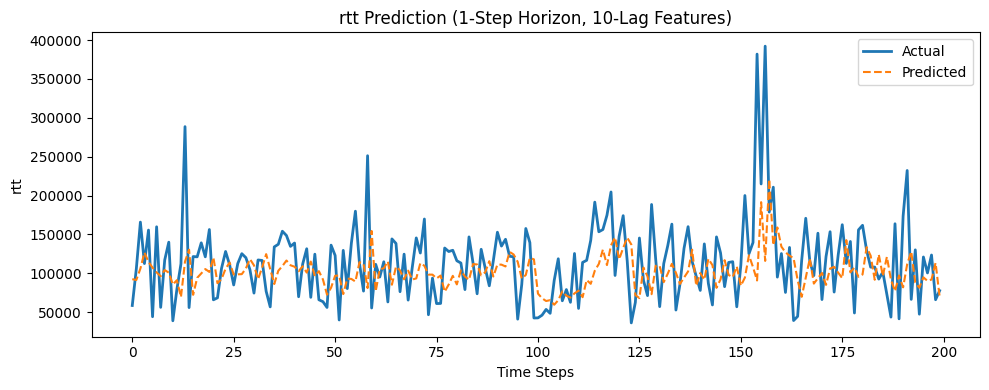

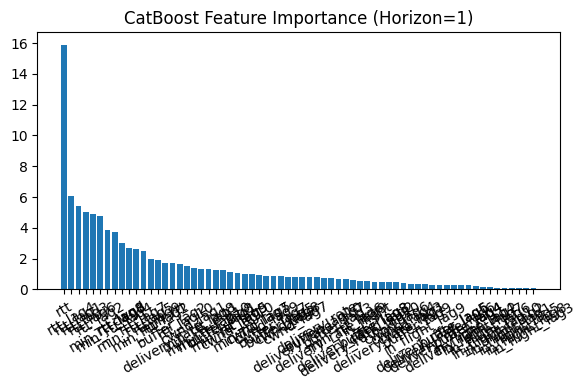

0:	learn: 40687.5279065	test: 41968.3529916	best: 41968.3529916 (0)	total: 163ms	remaining: 5m 26s
200:	learn: 14499.1791149	test: 15125.0327513	best: 15125.0327513 (200)	total: 20.2s	remaining: 3m 1s
400:	learn: 14226.4916405	test: 14821.1401424	best: 14821.0766067 (399)	total: 40.7s	remaining: 2m 42s
600:	learn: 14086.6915721	test: 14735.1349055	best: 14735.1349055 (600)	total: 1m 1s	remaining: 2m 22s
800:	learn: 13975.7446235	test: 14681.6554373	best: 14681.4820258 (798)	total: 1m 21s	remaining: 2m 1s
1000:	learn: 13884.1145221	test: 14664.5923859	best: 14663.2991453 (994)	total: 1m 45s	remaining: 1m 45s
1200:	learn: 13798.5588810	test: 14656.5468620	best: 14655.5586039 (1193)	total: 2m 6s	remaining: 1m 24s
1400:	learn: 13723.2261066	test: 14642.6646699	best: 14642.6095805 (1399)	total: 2m 26s	remaining: 1m 2s
1600:	learn: 13662.4088678	test: 14636.3786444	best: 14636.2500676 (1571)	total: 2m 46s	remaining: 41.6s
1800:	learn: 13596.6147537	test: 14633.9116632	best: 14632.6974502 (17

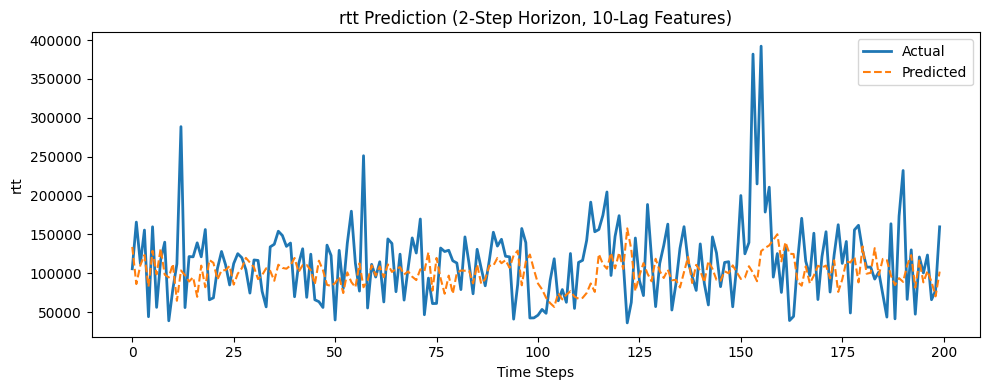

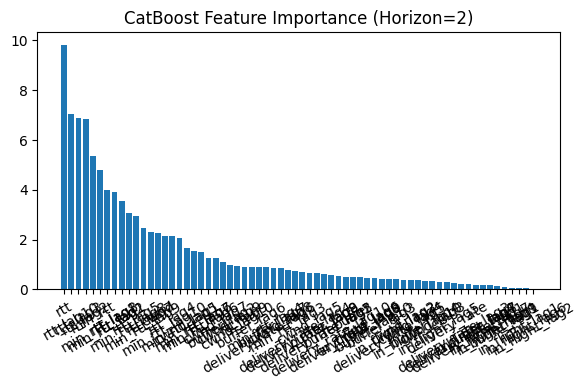

0:	learn: 40712.1481156	test: 42003.5956917	best: 42003.5956917 (0)	total: 196ms	remaining: 6m 31s
200:	learn: 14653.2695922	test: 15222.2829369	best: 15222.2829369 (200)	total: 21.2s	remaining: 3m 9s
400:	learn: 14391.5622213	test: 15013.8315182	best: 15013.8315182 (400)	total: 45.3s	remaining: 3m
600:	learn: 14250.4276743	test: 14937.7702511	best: 14937.6333508 (598)	total: 1m 14s	remaining: 2m 52s
800:	learn: 14145.3191259	test: 14896.9002350	best: 14896.1847862 (795)	total: 1m 37s	remaining: 2m 25s
1000:	learn: 14052.6754002	test: 14876.9580817	best: 14876.7859398 (996)	total: 1m 58s	remaining: 1m 57s
1200:	learn: 13974.9214255	test: 14871.8364906	best: 14870.9429459 (1195)	total: 2m 22s	remaining: 1m 34s
1400:	learn: 13903.4128441	test: 14865.4759947	best: 14865.4759947 (1400)	total: 2m 43s	remaining: 1m 9s
1600:	learn: 13840.4212832	test: 14860.5188323	best: 14858.4416232 (1465)	total: 3m 7s	remaining: 46.7s
1800:	learn: 13770.2830111	test: 14860.5302580	best: 14858.2502569 (1766

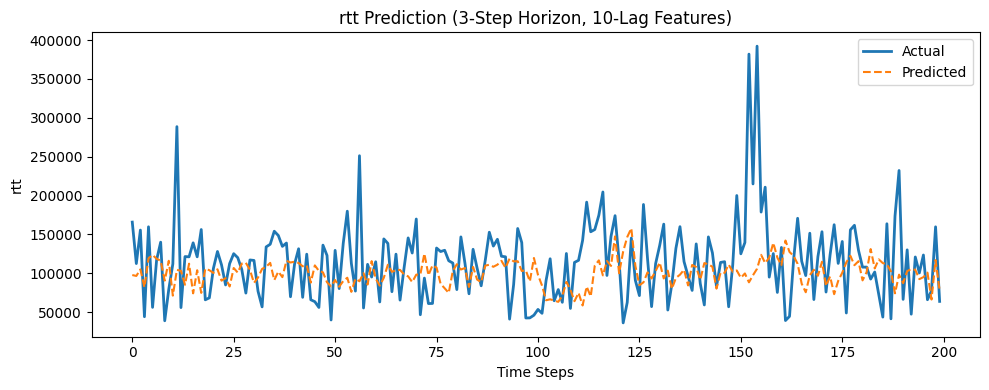

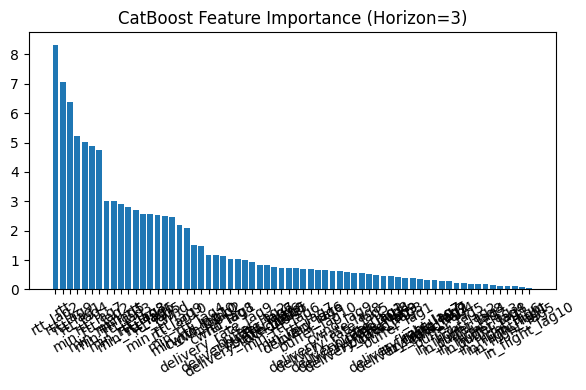

In [18]:
model, metrics = train_catboost_time_series(df, target_metric='rtt', n_lags=10, plot_num=200)


Preparing dataset for target='delivery_rate', lags=10, max_horizon=3
Adding lag features per session...


100%|██████████| 3595/3595 [00:46<00:00, 76.79it/s]


Training size: 640000, Test size: 160000
0:	learn: 5918795.5233164	test: 6282716.0323957	best: 6282716.0323957 (0)	total: 173ms	remaining: 5m 45s
200:	learn: 2584199.6833737	test: 2518596.6278729	best: 2518596.6278729 (200)	total: 20.4s	remaining: 3m 2s
400:	learn: 2389881.5401748	test: 2383601.5271412	best: 2383601.5271412 (400)	total: 41.4s	remaining: 2m 44s
600:	learn: 2315898.5265131	test: 2345878.1259589	best: 2345792.3659152 (599)	total: 1m 1s	remaining: 2m 23s
800:	learn: 2268984.9140122	test: 2328176.0273353	best: 2328176.0273353 (800)	total: 1m 23s	remaining: 2m 5s
1000:	learn: 2235293.2991387	test: 2322176.6589290	best: 2322176.6589290 (1000)	total: 1m 44s	remaining: 1m 44s
1200:	learn: 2209953.9031753	test: 2315972.6978400	best: 2315972.6978400 (1200)	total: 2m 6s	remaining: 1m 23s
1400:	learn: 2191388.3623432	test: 2316218.6780344	best: 2315416.5243374 (1387)	total: 2m 27s	remaining: 1m 3s
1600:	learn: 2175165.1290751	test: 2314786.7455932	best: 2314445.8285009 (1596)	total

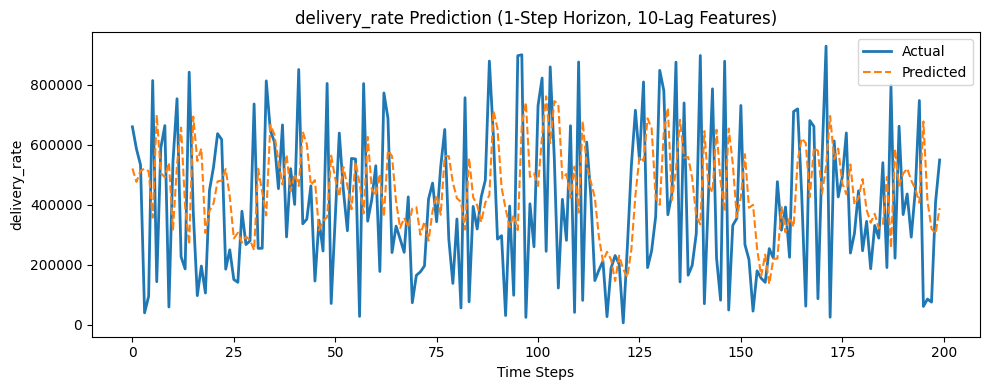

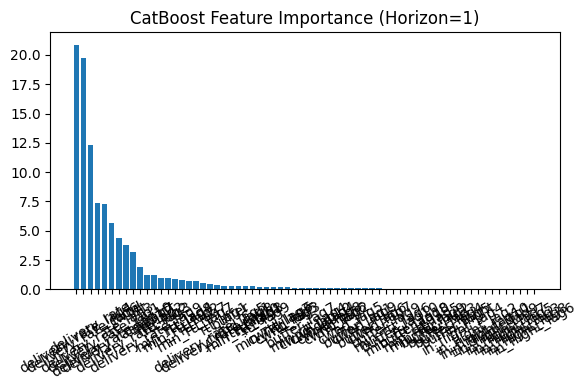

0:	learn: 5933979.6038415	test: 6292915.5921187	best: 6292915.5921187 (0)	total: 165ms	remaining: 5m 30s
200:	learn: 2484990.1608504	test: 2448940.7275484	best: 2448940.7275484 (200)	total: 20.3s	remaining: 3m 1s
400:	learn: 2337644.5996785	test: 2350145.7896083	best: 2347547.9612925 (399)	total: 41s	remaining: 2m 43s
600:	learn: 2279407.2437374	test: 2337217.0502237	best: 2337067.2237867 (598)	total: 1m	remaining: 2m 21s
800:	learn: 2246309.4996246	test: 2329406.1249131	best: 2329406.1249131 (800)	total: 1m 20s	remaining: 2m
1000:	learn: 2224427.2783221	test: 2324625.5187065	best: 2324507.3061384 (964)	total: 1m 40s	remaining: 1m 40s
1200:	learn: 2207378.3883404	test: 2321234.3351465	best: 2321234.3351465 (1200)	total: 2m 3s	remaining: 1m 22s
1400:	learn: 2190797.3733579	test: 2319605.1762106	best: 2319575.4918876 (1393)	total: 2m 23s	remaining: 1m 1s
1600:	learn: 2174770.6424503	test: 2316882.0303107	best: 2316783.7048710 (1596)	total: 2m 44s	remaining: 41s
1800:	learn: 2157589.19807

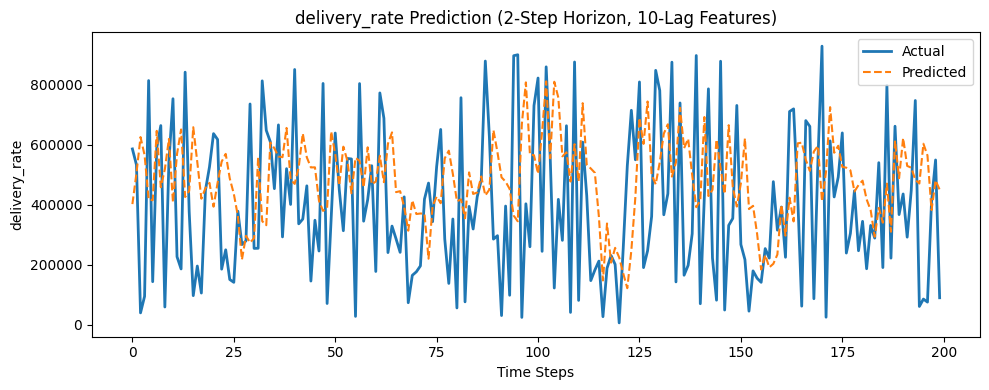

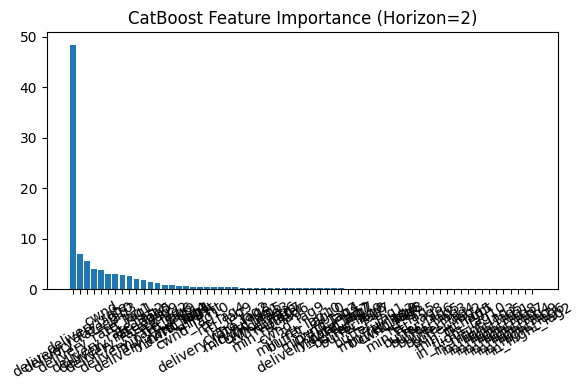

0:	learn: 5936140.6793102	test: 6297380.4622507	best: 6297380.4622507 (0)	total: 172ms	remaining: 5m 43s
200:	learn: 2570291.1440405	test: 2561750.6098625	best: 2561750.6098625 (200)	total: 20.6s	remaining: 3m 4s
400:	learn: 2439762.0838154	test: 2468848.7016050	best: 2468848.7016050 (400)	total: 40.9s	remaining: 2m 43s
600:	learn: 2386900.5765194	test: 2449518.6069233	best: 2449518.6069233 (600)	total: 1m 3s	remaining: 2m 28s
800:	learn: 2349722.7402899	test: 2439783.5141120	best: 2438388.5004129 (794)	total: 1m 24s	remaining: 2m 7s
1000:	learn: 2326657.8412668	test: 2435330.7211953	best: 2435330.7211953 (1000)	total: 1m 45s	remaining: 1m 45s
1200:	learn: 2301842.7770084	test: 2436080.4331641	best: 2434314.3237511 (1055)	total: 2m 6s	remaining: 1m 23s
1400:	learn: 2281351.1688013	test: 2435040.8809969	best: 2434314.3237511 (1055)	total: 2m 27s	remaining: 1m 3s
1600:	learn: 2266377.8627911	test: 2435798.4300984	best: 2434314.3237511 (1055)	total: 2m 46s	remaining: 41.5s
1800:	learn: 22

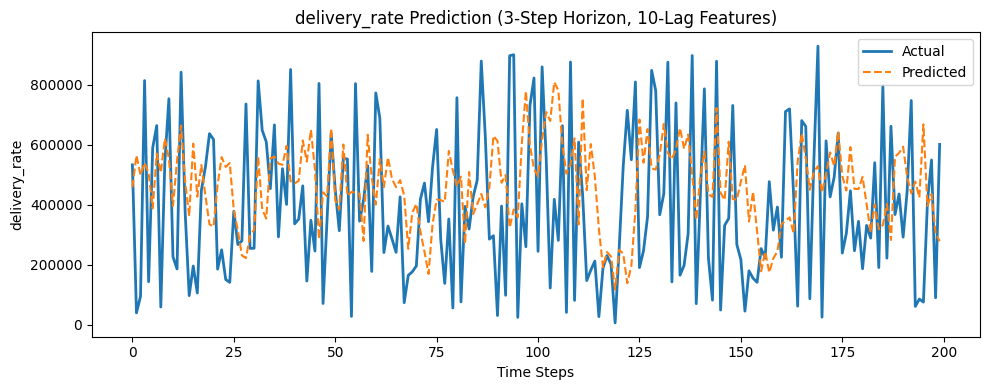

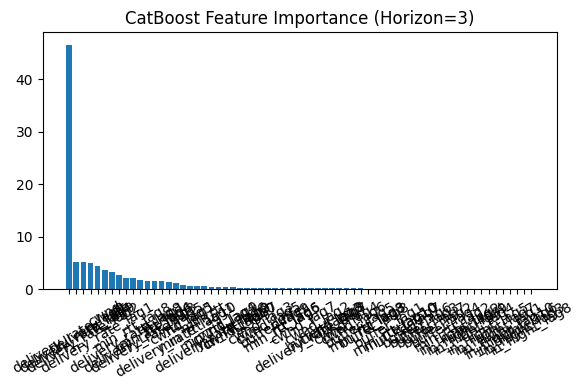

In [19]:
model, metrics = train_catboost_time_series(df, target_metric='delivery_rate', n_lags=10, plot_num=200)

In [6]:
# This is why we only select the first 800,000 rows of data: since their have the same expt_id values
df_subset = df.iloc[:800_000]

# Count unique expt_ids
unique_expt_ids = df_subset['expt_id'].nunique()
print(f"Number of unique expt_id values in the first 800,000 rows: {unique_expt_ids}")

df_subset = df.iloc[:1_000_000]

# Count unique expt_ids
unique_expt_ids = df_subset['expt_id'].nunique()
print(f"Number of unique expt_id values in the first 1,000,000 rows: {unique_expt_ids}")

Number of unique expt_id values in the first 800,000 rows: 1
Number of unique expt_id values in the first 1,000,000 rows: 2


In [11]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm


def train_catboost_time_series_quantile(
    df,
    target_metric='rtt',
    n_lags=1,
    max_horizon=3,
    sample_size=800_000,
    quantiles=[0.25, 0.75],
    plot=True,
    plot_num=200
):
    """
    Train CatBoost quantile regression models for multiple horizons on time-series data,
    and evaluate coverage and interval width.

    Returns
    -------
    models : dict[horizon][quantile] -> CatBoostRegressor
    metrics : dict[horizon] -> coverage, width, and MAE per quantile
    """
    print(f"\nPreparing dataset for target='{target_metric}', lags={n_lags}, max_horizon={max_horizon}")

    # Numeric columns + identifiers
    df_numeric = df.select_dtypes(include=[np.number]).copy()
    if 'session_id' in df.columns:
        df_numeric['session_id'] = df['session_id']
    if 'time' in df.columns:
        df_numeric['time'] = df['time']

    base_features = ['cwnd', 'in_flight', 'min_rtt', 'rtt', 'delivery_rate', 'buffer']
    feature_cols = [c for c in base_features if c in df_numeric.columns]

    # Build lag features per session
    dfs = []
    print("Adding lag features per session...")
    for sid, group in tqdm(df_numeric.groupby('session_id'), total=df_numeric['session_id'].nunique()):
        g = group.sort_values('time').copy()
        for lag in range(1, n_lags + 1):
            for col in feature_cols:
                g[f"{col}_lag{lag}"] = g[col].shift(lag)
        # Create targets for all horizons
        for horizon in range(1, max_horizon + 1):
            g[f"{target_metric}_next{horizon}"] = g[target_metric].shift(-horizon)
        dfs.append(g)

    df_model = (
        pd.concat(dfs, axis=0)
        .dropna(subset=[f"{target_metric}_next{h}" for h in range(1, max_horizon + 1)])
        .reset_index(drop=True)
    )

    if len(df_model) > sample_size:
        df_model = df_model.iloc[:sample_size]

    # Drop non-features
    df_model = df_model.drop(columns=['session_id', 'time'], errors='ignore')

    feature_cols = [
        c for c in df_model.columns
        if c.startswith(tuple(base_features)) and not c.startswith(f"{target_metric}_next")
    ]
    X = df_model[feature_cols]
    train_size = int(len(df_model) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]

    models = {}
    metrics = {}

    for horizon in range(1, max_horizon + 1):
        print(f"\n--- Horizon {horizon}-step ---")
        y = df_model[f"{target_metric}_next{horizon}"]
        y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

        models[horizon] = {}
        metrics[horizon] = {}
        preds = {}

        for q in quantiles:
            print(f"Training quantile={q}")
            cat_model = CatBoostRegressor(
                iterations=2000,
                learning_rate=0.05,
                depth=8,
                subsample=0.8,
                random_seed=42,
                loss_function=f'Quantile:alpha={q}',
                verbose=200
            )

            train_pool = Pool(X_train, y_train)
            test_pool = Pool(X_test, y_test)
            cat_model.fit(train_pool, eval_set=test_pool, use_best_model=False)

            y_pred = cat_model.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)

            models[horizon][q] = cat_model
            metrics[horizon][q] = {'test_MAE': mae}
            preds[q] = y_pred

        # ---- Compute coverage and interval width ----
        if len(quantiles) >= 2:
            q_low, q_high = min(quantiles), max(quantiles)
            pred_low, pred_high = preds[q_low], preds[q_high]

            inside = (y_test.values >= pred_low) & (y_test.values <= pred_high)
            coverage = inside.mean() * 100.0  # percentage
            avg_width = np.mean(pred_high - pred_low)

            metrics[horizon]['coverage'] = coverage
            metrics[horizon]['interval_width'] = avg_width

            print(f"Coverage: {coverage:.2f}% | Avg. interval width: {avg_width:.4f}")

        # ---- Plotting quantiles vs actual ----
        if plot and len(quantiles) >= 2:
            plt.figure(figsize=(10, 5))
            plt.plot(y_test.values[:plot_num], label='Actual', color='black', linewidth=2)

            q_low, q_high = min(quantiles), max(quantiles)
            plt.fill_between(
                np.arange(plot_num),
                preds[q_low][:plot_num],
                preds[q_high][:plot_num],
                color='skyblue',
                alpha=0.4,
                label=f'{int(q_low*100)}–{int(q_high*100)}% range'
            )

            plt.plot(preds[q_low][:plot_num], linestyle='--', color='blue', alpha=0.7, label=f'q={q_low}')
            plt.plot(preds[q_high][:plot_num], linestyle='--', color='blue', alpha=0.7, label=f'q={q_high}')

            plt.title(f'{target_metric} Quantile Predictions ({horizon}-Step Horizon)')
            plt.xlabel('Time Steps')
            plt.ylabel(target_metric)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return models, metrics



Preparing dataset for target='rtt', lags=10, max_horizon=1
Adding lag features per session...


100%|██████████| 3595/3595 [00:49<00:00, 72.24it/s]



--- Horizon 1-step ---
Training quantile=0.25
0:	learn: 14373.6896229	test: 14273.7972316	best: 14273.7972316 (0)	total: 141ms	remaining: 4m 41s
200:	learn: 4394.4928608	test: 5038.4980805	best: 5038.4980805 (200)	total: 21.7s	remaining: 3m 14s
400:	learn: 4290.9915320	test: 4933.4589035	best: 4933.3199499 (393)	total: 43.2s	remaining: 2m 52s
600:	learn: 4235.3825341	test: 4880.6712360	best: 4880.6712360 (600)	total: 1m 4s	remaining: 2m 30s
800:	learn: 4200.7460654	test: 4852.5126333	best: 4852.5126333 (800)	total: 1m 25s	remaining: 2m 8s
1000:	learn: 4174.3453523	test: 4838.5292464	best: 4838.5292464 (1000)	total: 1m 46s	remaining: 1m 46s
1200:	learn: 4154.7259028	test: 4832.4460288	best: 4831.9457431 (1186)	total: 2m 7s	remaining: 1m 25s
1400:	learn: 4134.5647740	test: 4827.7846760	best: 4827.6115333 (1390)	total: 2m 28s	remaining: 1m 3s
1600:	learn: 4117.9949921	test: 4824.8109031	best: 4824.7905649 (1597)	total: 2m 51s	remaining: 42.7s
1800:	learn: 4102.1907495	test: 4822.9253770	

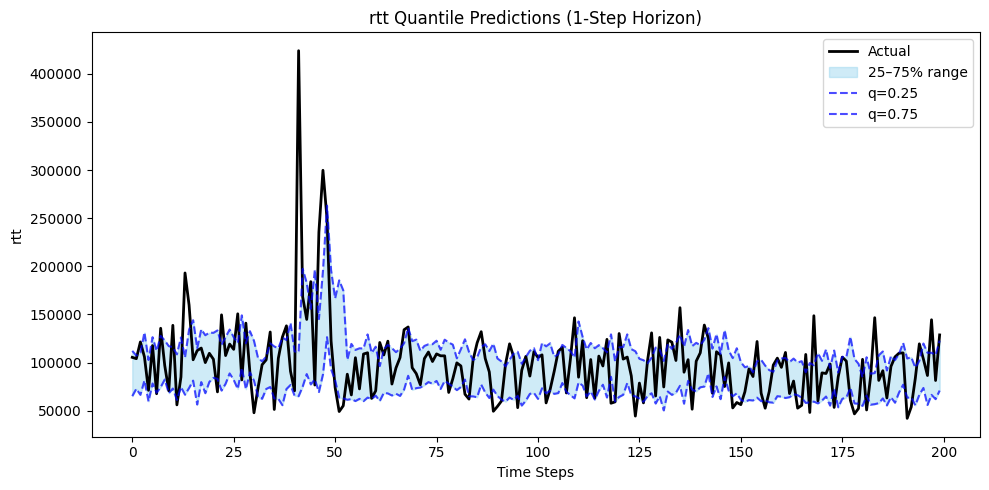

In [13]:
models, metrics = train_catboost_time_series_quantile(
    df=df,
    target_metric='rtt',
    n_lags=10,
    max_horizon=1,
    quantiles=[0.25, 0.75],
    plot=True
)


Preparing dataset for target='rtt', lags=10, max_horizon=1
Adding lag features per session...


100%|██████████| 3595/3595 [00:48<00:00, 73.97it/s]



--- Horizon 1-step ---
Training quantile=0.05
0:	learn: 3630.7193274	test: 3656.9596515	best: 3656.9596515 (0)	total: 145ms	remaining: 4m 49s
200:	learn: 1218.8760876	test: 1374.0214360	best: 1374.0214360 (200)	total: 20.8s	remaining: 3m 5s
400:	learn: 1041.4605103	test: 1304.5316542	best: 1304.5316542 (400)	total: 41.1s	remaining: 2m 43s
600:	learn: 1024.3496193	test: 1295.7467920	best: 1295.7467920 (600)	total: 1m	remaining: 2m 20s
800:	learn: 1013.9050455	test: 1286.5000500	best: 1286.3165524 (793)	total: 1m 19s	remaining: 1m 59s
1000:	learn: 1006.2910266	test: 1280.3919251	best: 1280.0682986 (975)	total: 1m 39s	remaining: 1m 38s
1200:	learn: 1000.2017212	test: 1280.5321061	best: 1279.9834164 (1082)	total: 2m 1s	remaining: 1m 20s
1400:	learn: 995.5833151	test: 1279.6708969	best: 1279.4634402 (1296)	total: 2m 20s	remaining: 1m
1600:	learn: 990.9660667	test: 1281.1252341	best: 1279.4634402 (1296)	total: 2m 39s	remaining: 39.8s
1800:	learn: 987.7688391	test: 1283.4930548	best: 1279.46

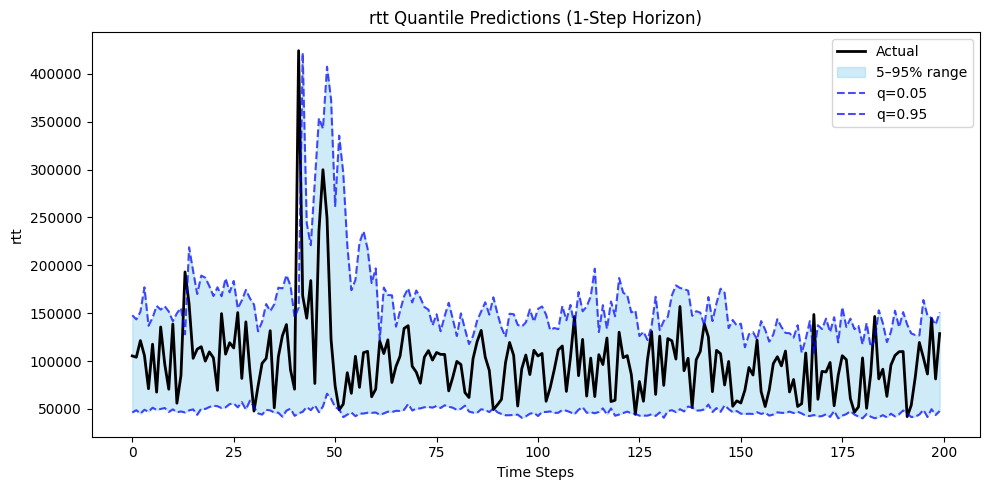

In [14]:
models, metrics = train_catboost_time_series_quantile(
    df=df,
    target_metric='rtt',
    n_lags=10,
    max_horizon=1,
    quantiles=[0.05, 0.95],
    plot=True
)


Preparing dataset for target='delivery_rate', lags=10, max_horizon=1
Adding lag features per session...


100%|██████████| 3595/3595 [42:55<00:00,  1.40it/s]   



--- Horizon 1-step ---
Training quantile=0.25
0:	learn: 1770293.4203795	test: 1821656.5520566	best: 1821656.5520566 (0)	total: 159ms	remaining: 5m 17s
200:	learn: 1068992.1697463	test: 946073.4104892	best: 946073.4104892 (200)	total: 21.9s	remaining: 3m 15s
400:	learn: 1013413.2062597	test: 898960.4149652	best: 898960.4149652 (400)	total: 44.2s	remaining: 2m 56s
600:	learn: 989804.2065772	test: 885956.2454750	best: 885956.2454750 (600)	total: 1m 5s	remaining: 2m 31s
800:	learn: 971189.0831834	test: 879610.0992472	best: 879534.1396250 (793)	total: 1m 26s	remaining: 2m 10s
1000:	learn: 959242.8649993	test: 877769.3058822	best: 877769.3058822 (1000)	total: 1m 45s	remaining: 1m 45s
1200:	learn: 949546.5688059	test: 876858.5311569	best: 876805.6584154 (1170)	total: 2m 5s	remaining: 1m 23s
1400:	learn: 941664.5647260	test: 876609.3013261	best: 876507.7751507 (1359)	total: 2m 24s	remaining: 1m 1s
1600:	learn: 934875.3938722	test: 875792.2677258	best: 875792.2677258 (1600)	total: 2m 42s	remai

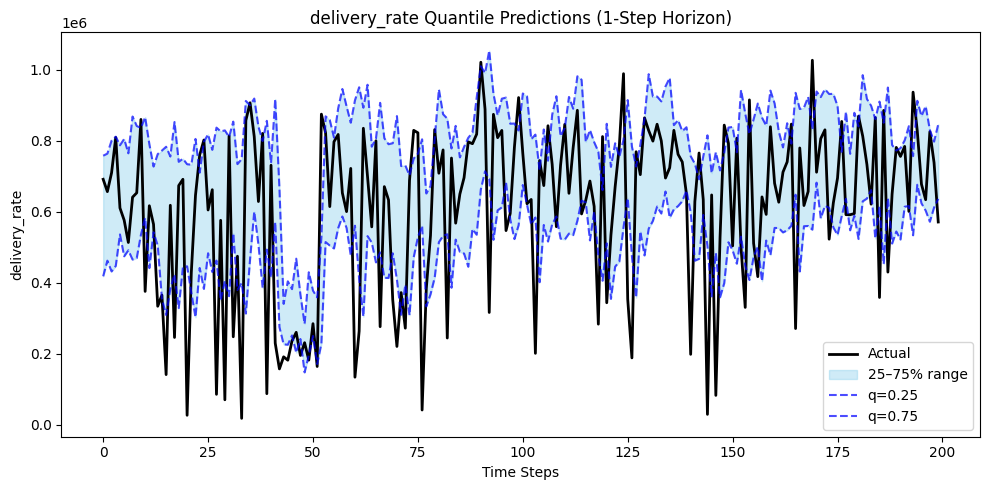

In [15]:
models, metrics = train_catboost_time_series_quantile(
    df=df,
    target_metric='delivery_rate',
    n_lags=10,
    max_horizon=1,
    quantiles=[0.25, 0.75],
    plot=True
)


Preparing dataset for target='delivery_rate', lags=10, max_horizon=1
Adding lag features per session...


100%|██████████| 3595/3595 [00:46<00:00, 76.96it/s]



--- Horizon 1-step ---
Training quantile=0.05
0:	learn: 400434.9222288	test: 403390.5912747	best: 403390.5912747 (0)	total: 142ms	remaining: 4m 43s
200:	learn: 353857.7101233	test: 353272.9538151	best: 353162.3500270 (197)	total: 18.6s	remaining: 2m 46s
400:	learn: 344158.0588362	test: 346259.9859316	best: 346259.9859316 (400)	total: 38.7s	remaining: 2m 34s
600:	learn: 339676.8353544	test: 344549.9793576	best: 344507.0623591 (595)	total: 56.1s	remaining: 2m 10s
800:	learn: 337061.5876228	test: 343814.0751635	best: 343790.7968015 (756)	total: 1m 13s	remaining: 1m 49s
1000:	learn: 334697.1939635	test: 343967.0509088	best: 343574.6837713 (891)	total: 1m 31s	remaining: 1m 31s
1200:	learn: 333592.7892192	test: 344274.9321001	best: 343574.6837713 (891)	total: 1m 47s	remaining: 1m 11s
1400:	learn: 332288.2025611	test: 345689.0990935	best: 343574.6837713 (891)	total: 2m 3s	remaining: 53s
1600:	learn: 331410.2425917	test: 347017.4324913	best: 343574.6837713 (891)	total: 2m 19s	remaining: 34.7s

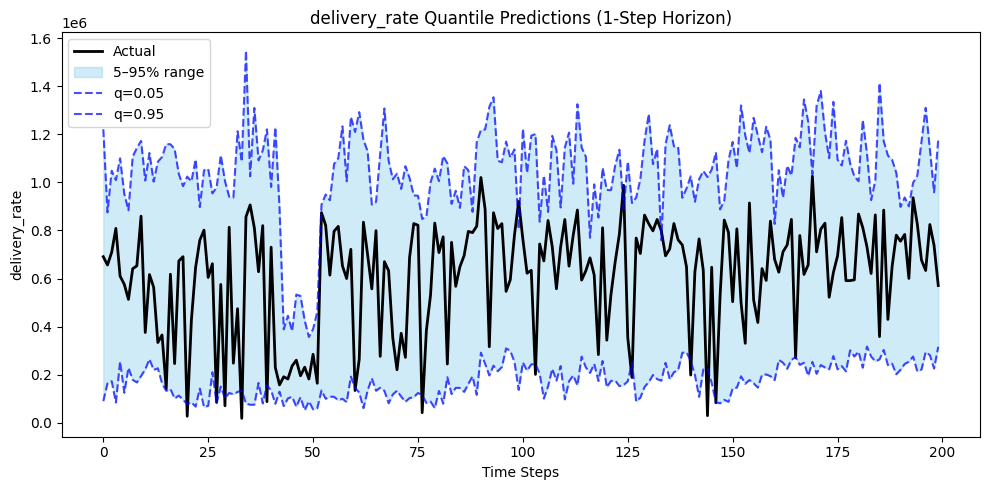

In [16]:
models, metrics = train_catboost_time_series_quantile(
    df=df,
    target_metric='delivery_rate',
    n_lags=10,
    max_horizon=1,
    quantiles=[0.05, 0.95],
    plot=True
)